In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
mut_rate_4 = pd.read_csv('/home/Users/rdd4/bronko_test/simulated_hpv_runs/HPV_mut_rate_4_0.01/sample_1/rep1_R1_k21/rep1_R1.tsv', delimiter='\t')
baseline = pd.read_csv('/home/Users/rdd4/bronko_test/simulated_hpv_runs/OR4/HPV_baseline_0.01/sample_1/rep1_R1_k21/rep1_R1.tsv', delimiter='\t')
covid = pd.read_csv('/home/Users/rdd4/bronko/prerelease_testing/test_outputs/NY_biotia/SRR23007203_k19/SRR23007203.tsv', delimiter='\t')
covid2 = pd.read_csv('/home/Users/rdd4/bronko/prerelease_testing/test_outputs/NY_biotia/SRR23007204_k19/SRR23007204.tsv', delimiter='\t')
inf = pd.read_csv('/home/Users/rdd4/bronko/prerelease_testing/test_outputs/UW_influenza/SRR33673662_k19/SRR33673662.tsv', delimiter='\t')

In [25]:
def plot_minor_af_distribution(df, bins=100, xmax=0.01):
    """Plot histogram + KDE of all minor allele frequencies (including 0s)."""
    df['A_total'] = df['A'] + df['a']
    df['C_total'] = df['C'] + df['c']
    df['G_total'] = df['G'] + df['g']
    df['T_total'] = df['T'] + df['t']

    # Total depth
    df['depth'] = df[['A_total','C_total','G_total','T_total']].sum(axis=1)

    # Allele frequencies
    for base in ['A','C','G','T']:
        df[f'{base}_af'] = df[f'{base}_total'] / df['depth']

    # Minor variant allele frequency
    df['minor_af'] = df[['A_af','C_af','G_af','T_af']].apply(
        lambda x: sorted(x, reverse=True)[1] if x.max() > 0 else 0, axis=1
    )
    
    subset = df[df['minor_af'] < xmax]
    subset = subset[subset['minor_af'] > 0]['minor_af']

    plt.figure(figsize=(6,4))
    sns.histplot(subset, bins=bins, kde=True, color='steelblue')
    plt.xlabel('Minor allele frequency')
    plt.ylabel('Count')
    plt.title('Distribution of minor allele frequencies (including 0s)')
    plt.tight_layout()
    # plt.yscale('log')
    plt.xlim(0, xmax)
    plt.ylim(bottom=0)
    plt.show()

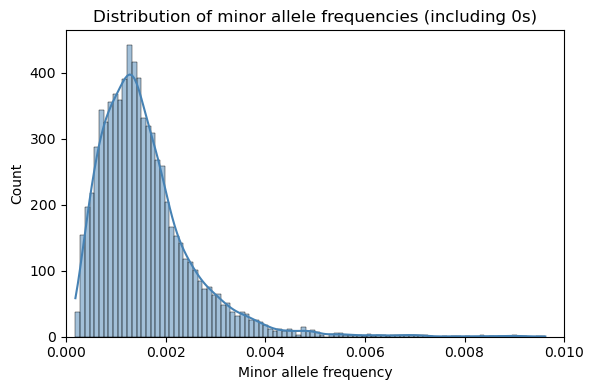

In [26]:
plot_minor_af_distribution(mut_rate_4)

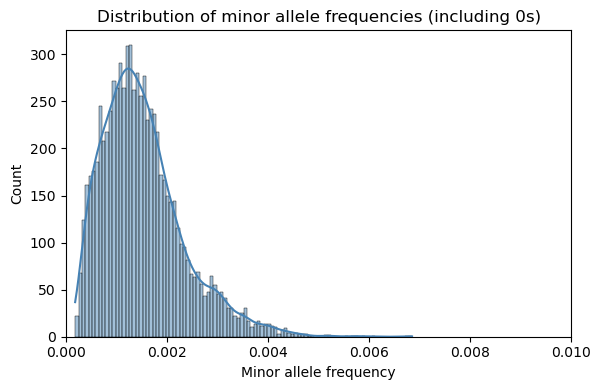

In [27]:
plot_minor_af_distribution(baseline, xmax=0.01)

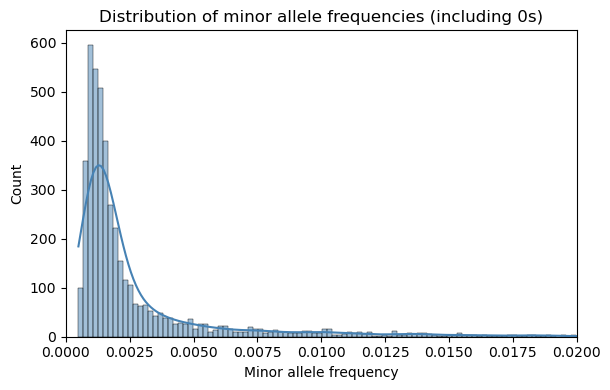

In [28]:
plot_minor_af_distribution(covid, xmax=0.02)

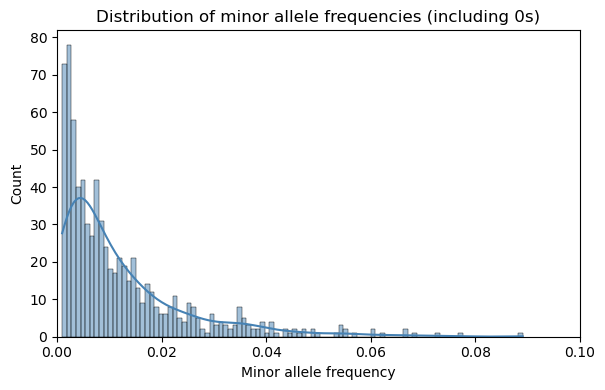

In [29]:
plot_minor_af_distribution(covid2, xmax=0.1)

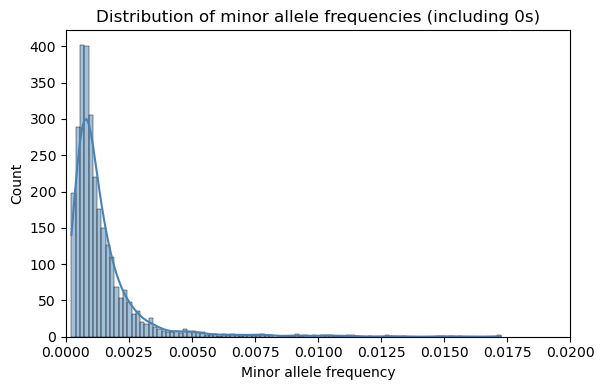

In [30]:
plot_minor_af_distribution(inf, xmax=0.02)

In [32]:
def roll_mean_ignore_zeros(x):
    nz = x[x > 0]
    return nz.mean() if len(nz) > 0 else 0

def roll_std_ignore_zeros(x):
    nz = x[x > 0]
    return nz.std() if len(nz) > 1 else 0

def plot_variation(df, ymax=None, N=200, std_m=3):
    df['A_total'] = df['A'] + df['a']
    df['C_total'] = df['C'] + df['c']
    df['G_total'] = df['G'] + df['g']
    df['T_total'] = df['T'] + df['t']

    # Total depth
    df['depth'] = df[['A_total','C_total','G_total','T_total']].sum(axis=1)

    # Allele frequencies
    for base in ['A','C','G','T']:
        df[f'{base}_af'] = df[f'{base}_total'] / df['depth']

    # Minor variant allele frequency
    df['minor_af'] = df[['A_af','C_af','G_af','T_af']].apply(
        lambda x: sorted(x, reverse=True)[1] if x.max() > 0 else 0, axis=1
    )

    # Exclude zeros for summary stats
    nonzero_minor = df.loc[df['minor_af'] > 0, 'minor_af']
    mean_minor = nonzero_minor.mean()
    std_minor = nonzero_minor.std()

    df['rolling_mean'] = df['minor_af'].rolling(window=N, center=True).apply(roll_mean_ignore_zeros, raw=False)
    df['rolling_std']  = df['minor_af'].rolling(window=N, center=True).apply(roll_std_ignore_zeros, raw=False)
    # df['rolling_mean'] = df['minor_af'].rolling(window=N, center=True).mean()
    # df['rolling_std']  = df['minor_af'].rolling(window=N, center=True).std()


    df['threshold'] = df['rolling_mean'] + std_m * df['rolling_std']
    above_thresh = (df['minor_af'] >= df['threshold']).sum()
    print(f"Variants above threshold: {above_thresh} / {len(df)} "
          f"({above_thresh/len(df)*100:.2f}%)")

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(10,4))

    ax1.scatter(df.index, df['minor_af'], s=10, alpha=0.5, label='Minor AF')
    ax1.axhline(mean_minor, color='red', linestyle='--', label=f'Mean = {mean_minor:.4f}')
    ax1.axhline(mean_minor + std_minor, color='orange', linestyle=':', label=f'+1 SD = {mean_minor+std_minor:.4f}')
    ax1.axhline(mean_minor - std_minor, color='orange', linestyle=':', label=f'-1 SD = {mean_minor-std_minor:.4f}')
    ax1.plot(df.index, df['rolling_mean'], color='black', linewidth=2, label=f'Rolling mean (N={N})')
    ax1.plot(df.index, df['rolling_mean'] + std_m*df['rolling_std'], color='black', linestyle=":", linewidth=1)
    ax1.plot(df.index, df['rolling_mean'] - std_m*df['rolling_std'], color='black', linestyle=":", linewidth=1)
    ax1.set_xlabel('Position (row index)')
    ax1.set_ylabel('Minor allele frequency')
    ax1.legend(loc='upper left')
    ax1.set_ylim(bottom=0)
    if ymax:
        ax1.set_ylim(0, ymax)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['depth'], color='gray', alpha=0.4, label='Depth')
    ax2.set_ylabel('Depth')
    ax2.legend(loc='upper right')
    ax2.set_ylim(bottom=0)
    plt.ylim(bottom=0)

    plt.title('Minor variants per position with depth (nonzero mean)')
    plt.tight_layout()
    plt.show()

Variants above threshold: 232 / 7906 (2.93%)


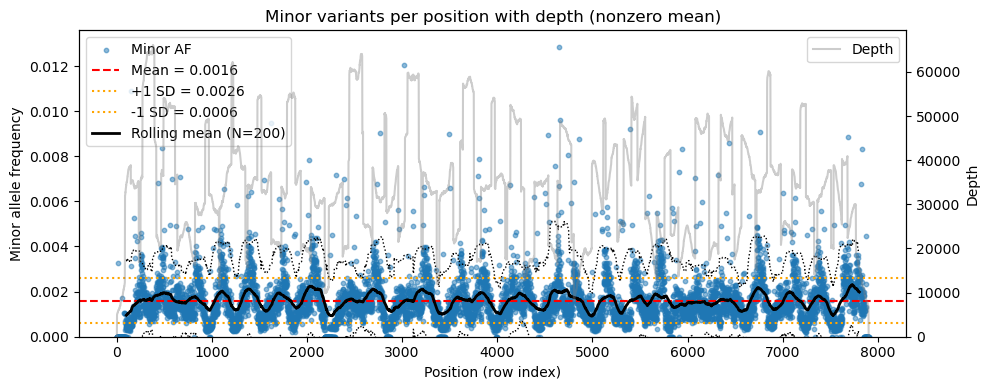

In [33]:
plot_variation(mut_rate_4, std_m=2, N=200)

Variants above threshold: 240 / 7906 (3.04%)


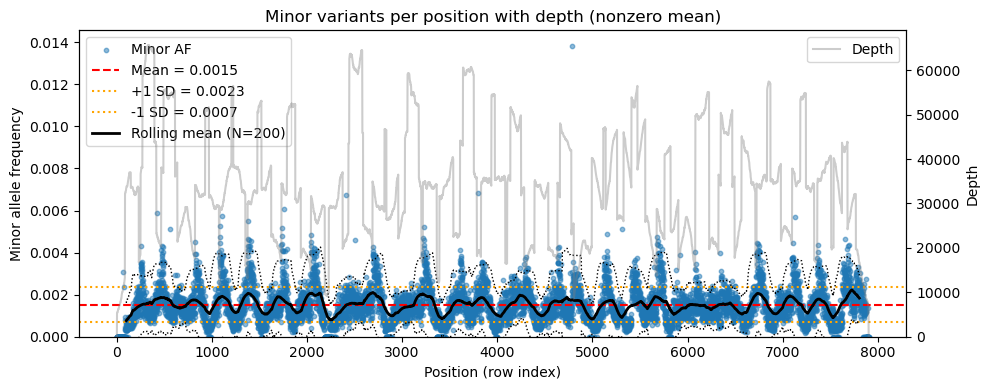

In [58]:
plot_variation(baseline, std_m=2, N=200)

Variants above threshold: 254 / 29814 (0.85%)


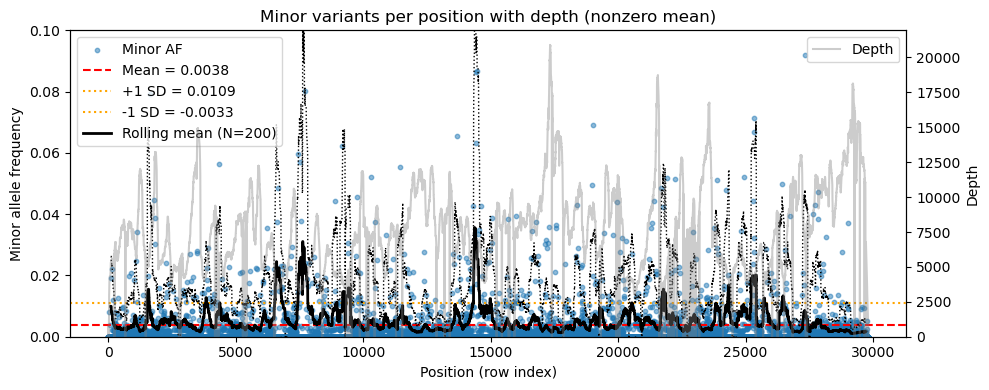

In [34]:
plot_variation(covid, ymax=0.1, std_m=2, N=200)

Variants above threshold: 1118 / 29814 (3.75%)


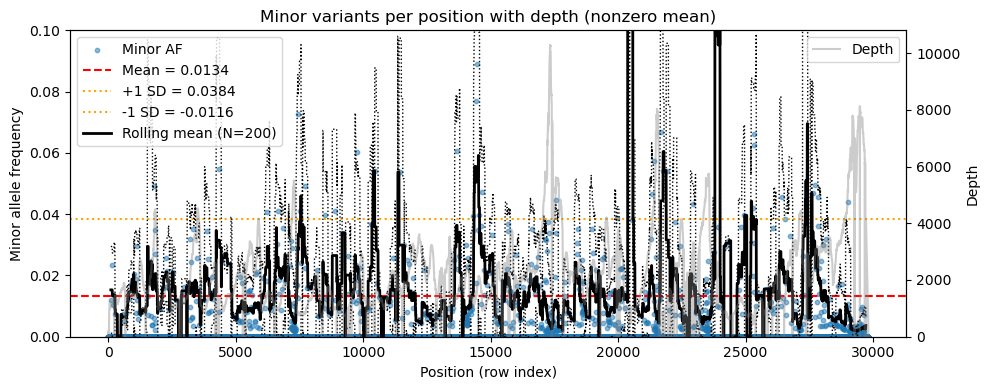

In [35]:
plot_variation(covid2, ymax=0.1, std_m=2, N=200)

Variants above threshold: 133 / 13543 (0.98%)


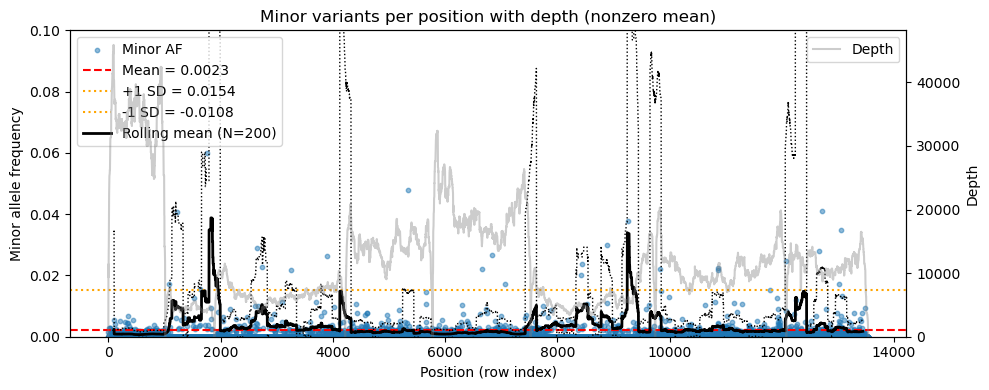

In [63]:
plot_variation(inf, ymax=0.1, std_m=2, N=200)

Variants above threshold: 133 / 13543 (0.98%)


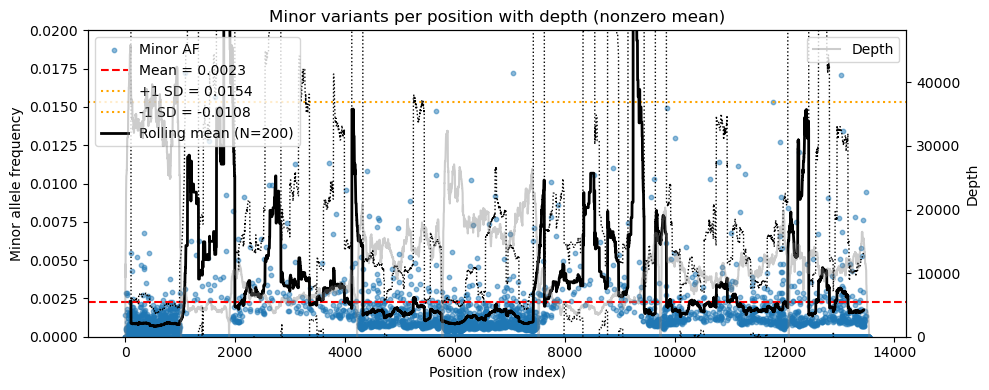

In [64]:
plot_variation(inf, ymax=0.02, std_m=2, N=200)

In [ ]:
import numpy as np
from scipy.stats import t

def thompson_tau_filter(x, alpha=0.001):
    """Remove outliers using Thompson's Tau test until none remain."""
    x = np.array([v for v in x if v > 0], dtype=float)
    if len(x) < 3:
        return x
    changed = True
    while changed and len(x) >= 3:
        mean = np.mean(x)
        std = np.std(x, ddof=1)
        if std == 0:
            break
        n = len(x)
        t_val = t.ppf(1 - alpha / n, n - 2)
        tau = t_val * (n - 1) / (np.sqrt(n) * np.sqrt(n - 2 + t_val**2))
        diffs = np.abs(x - mean)
        max_diff = diffs.max()
        if max_diff > tau * std:
            x = np.delete(x, np.argmax(diffs))
        else:
            changed = False
    return x

def roll_mean_tau(window):
    x = thompson_tau_filter(window)
    return np.max(x) if len(x) > 0 else np.nan

def roll_std_tau(window):
    x = thompson_tau_filter(window)
    return np.std(x, ddof=1) if len(x) > 1 else np.nan

# --- Main function ---
def plot_variation_tau(df, ymax=None, N=200, std_m=3):
    df['A_total'] = df['A'] + df['a']
    df['C_total'] = df['C'] + df['c']
    df['G_total'] = df['G'] + df['g']
    df['T_total'] = df['T'] + df['t']

    df['depth'] = df[['A_total','C_total','G_total','T_total']].sum(axis=1)

    for base in ['A','C','G','T']:
        df[f'{base}_af'] = df[f'{base}_total'] / df['depth']

    df['minor_af'] = df[['A_af','C_af','G_af','T_af']].apply(
        lambda x: sorted(x, reverse=True)[1] if x.max() > 0 else 0, axis=1
    )

    nonzero_minor = df.loc[df['minor_af'] > 0, 'minor_af']
    mean_minor = nonzero_minor.mean()
    std_minor = nonzero_minor.std()

    df['rolling_mean'] = df['minor_af'].rolling(window=N, center=True).apply(roll_mean_tau, raw=False)
    df['rolling_std']  = df['minor_af'].rolling(window=N, center=True).apply(roll_std_tau, raw=False)
    
    df['threshold'] = df['rolling_mean'] + std_m * df['rolling_std']
    above_thresh = (df['minor_af'] >= df['threshold']).sum()
    print(f"Variants above threshold: {above_thresh} / {len(df)} "
          f"({above_thresh/len(df)*100:.2f}%)")


    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(10,4))
    ax1.scatter(df.index, df['minor_af'], s=10, alpha=0.5, label='Minor AF')
    ax1.axhline(mean_minor, color='red', linestyle='--', label=f'Mean = {mean_minor:.4f}')
    ax1.axhline(mean_minor + std_minor, color='orange', linestyle=':', label=f'+1 SD = {mean_minor+std_minor:.4f}')
    ax1.axhline(mean_minor - std_minor, color='orange', linestyle=':', label=f'-1 SD = {mean_minor-std_minor:.4f}')
    ax1.plot(df.index, df['rolling_mean'], color='black', linewidth=2, label=f'Rolling mean (Tau, N={N})')
    ax1.plot(df.index, df['rolling_mean'] + std_m*df['rolling_std'], color='black', linestyle=":", linewidth=1)
    ax1.plot(df.index, df['rolling_mean'] - std_m*df['rolling_std'], color='black', linestyle=":", linewidth=1)
    ax1.set_xlabel('Position (row index)')
    ax1.set_ylabel('Minor allele frequency')
    ax1.legend(loc='upper left')
    ax1.set_ylim(bottom=0)
    if ymax:
        ax1.set_ylim(0, ymax)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['depth'], color='gray', alpha=0.4, label='Depth')
    ax2.set_ylabel('Depth')
    ax2.legend(loc='upper right')
    ax2.set_ylim(bottom=0)
    plt.ylim(bottom=0)

    plt.title('Minor variants per position with Thompson Tau outlier filtering')
    plt.tight_layout()
    plt.show()

Variants above threshold: 232 / 7906 (2.93%)


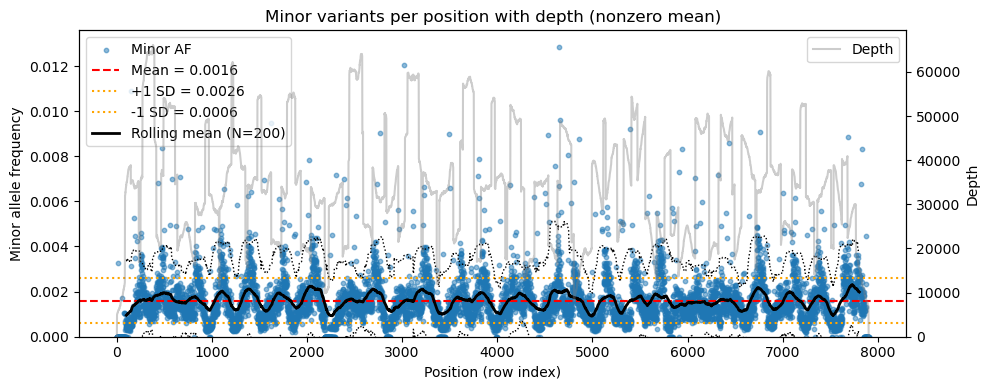

In [12]:
plot_variation(mut_rate_4, std_m=2, N=200)

Variants above threshold: 118 / 7906 (1.49%)


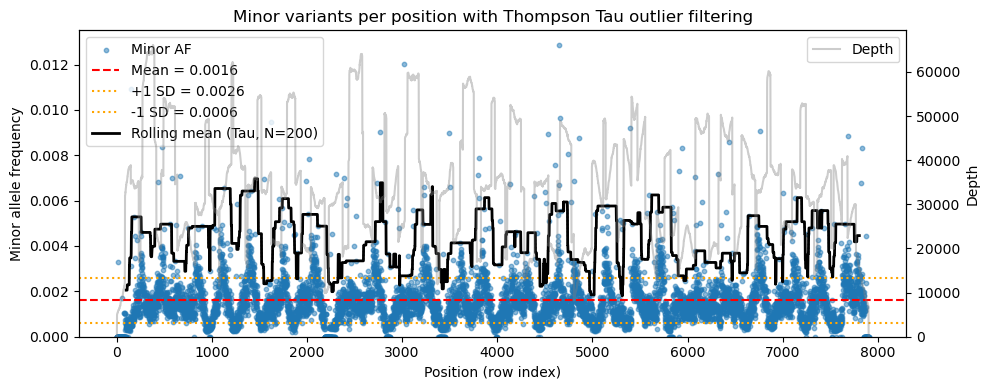

In [21]:
plot_variation_tau(mut_rate_4, std_m=0, N=200)

Variants above threshold: 209 / 7906 (2.64%)


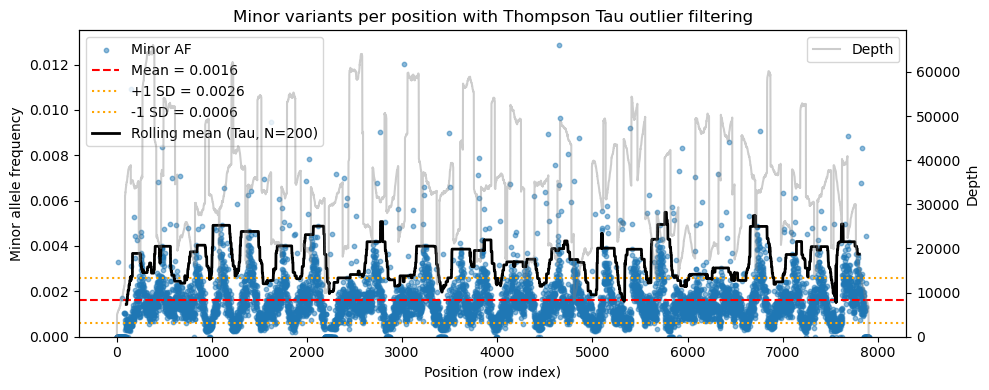

In [19]:
plot_variation_tau(mut_rate_4, std_m=0, N=200)

Variants above threshold: 425 / 29814 (1.43%)


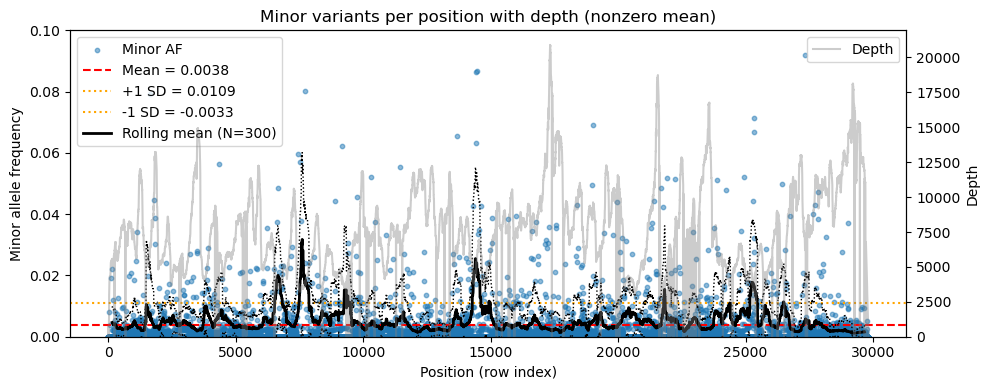

In [16]:
plot_variation(covid, ymax=0.1, std_m=1, N=300)

Variants above threshold: 567 / 29814 (1.90%)


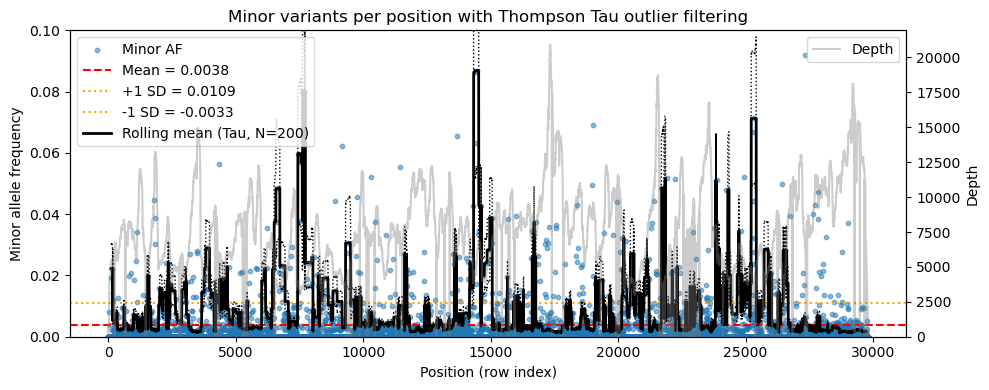

In [23]:
plot_variation_tau(covid, ymax=0.1, std_m=1, N=200)

Variants above threshold: 234 / 29814 (0.78%)


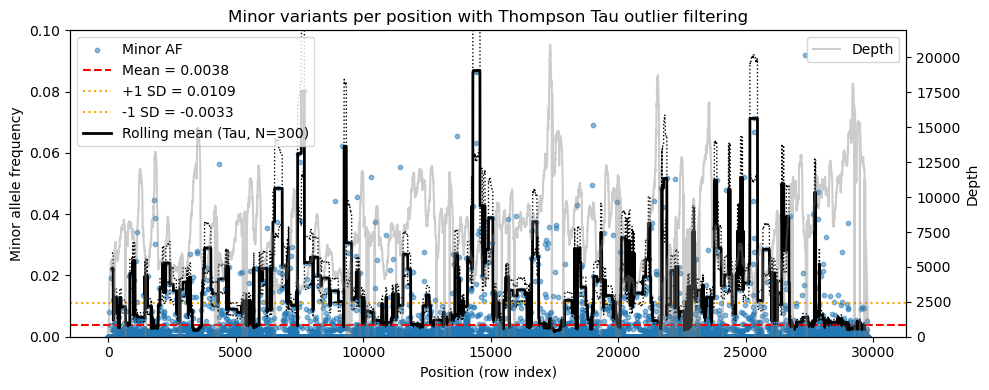

In [ ]:
plot_variation_tau(covid, ymax=0.1, std_m=1, N=200)

Variants above threshold: 133 / 13543 (0.98%)


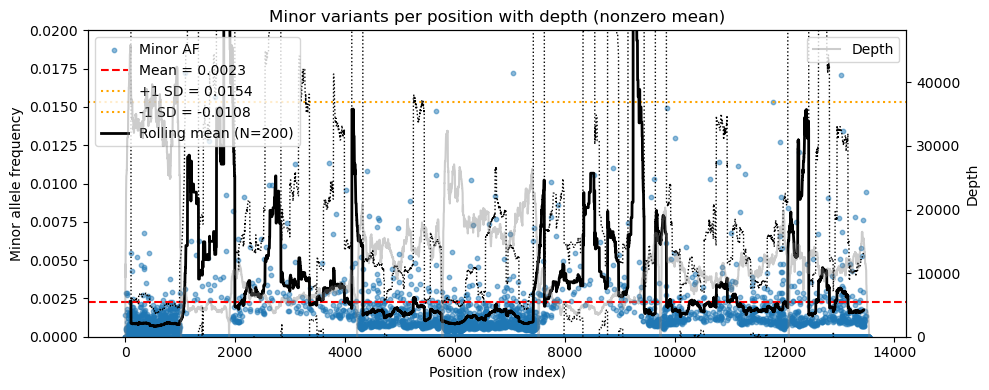

In [21]:
plot_variation(inf, ymax=0.02, std_m=2, N=200)

Variants above threshold: 252 / 13543 (1.86%)


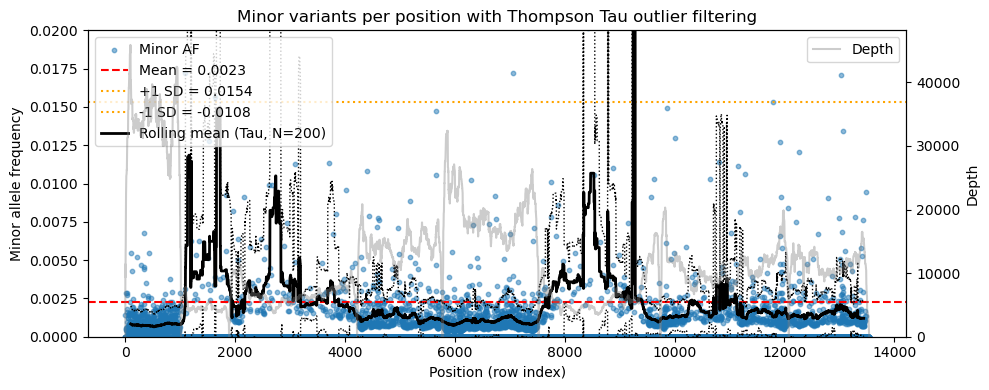

In [22]:
plot_variation_tau(inf, ymax=0.02, std_m=2, N=200)

Variants above threshold: 145 / 13543 (1.07%)


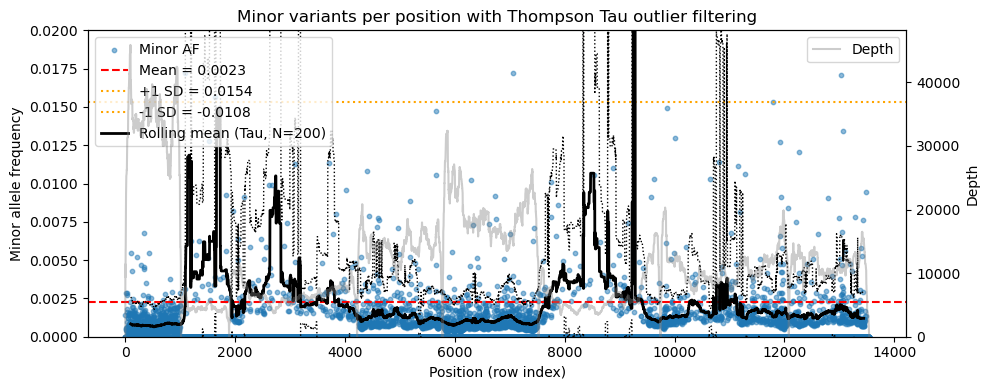

In [23]:
plot_variation_tau(inf, ymax=0.02, std_m=3, N=200)